# XOR Task

This notebook trains a rate RNN and convert it into a functional spiking RNN for the XOR Task.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import numpy as np
import pandas as pd
import torch
import scipy.io as sio
import matplotlib.pyplot as plt
from rate import FR_RNN_dale, set_gpu, create_default_config
from rate.model import loss_op
from rate import TaskFactory
from spiking.LIF_network_fnc import LIF_network_fnc
from spiking.lambda_grid_search import lambda_grid_search

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set up GPU if available, otherwise use CPU
device = set_gpu('0', 0.3)
# Configure network parameters
N = 200      # Number of neurons
P_inh = 0.2  # Proportion of inhibitory neurons
P_rec = 0.2  # Recurrent connection probability
config = create_default_config(N=N, P_inh=P_inh, P_rec=P_rec)

# Initialize network
w_in = torch.randn(200, 2, device=device)
w_out = torch.randn(1, 200, device=device) / 100

net = FR_RNN_dale(
    N=config.N,
    P_inh=config.P_inh,
    P_rec=config.P_rec,
    w_in=w_in,
    w_out=w_out,
    som_N=0,
    w_dist='gaus', 
    gain=1.5, 
    apply_dale=True,
    device=device
)
w0 = net.w.clone().detach()
# Generate task data
settings = {
            'T': 300, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 50, # input stim duration (in steps)
            'delay': 10, # delay b/w the two stimuli (in steps)
            'DeltaT': 1, # sampling rate
            'taus': [20], # decay time-constants (in steps)
            'task': 'xor', # task name
            }


In [ ]:
training_params = {
    'learning_rate': 0.1,
    'loss_threshold': 0.1,
    'eval_freq': 100,
    'eval_tr': 100,
    'eval_amp_threh': 0.3,
    'activation': 'sigmoid',
    'loss_fn': 'L2', 
    'P_rec': 0.20,
    'optimizer': 'eg'
}

# exponentiated gradient optimizer
from rate.eg_optimizer import ExponentiatedGradient
import torch.optim as optim

eg_params = []
adam_params = []

for name, param in net.named_parameters():
    if name == 'w':
        # Apply EG only to the recurrent weight magnitudes 'w'
        eg_params.append(param)
    else:
        # Apply Adam to all other parameters (w_in, w_out, b_out)
        adam_params.append(param)

# Create two optimizers
optimizer_eg = ExponentiatedGradient(eg_params, 
                                    lr=training_params['learning_rate'],
                                    weight_decay=training_params.get('weight_decay', 0.0))

optimizer_adam = optim.Adam(adam_params, lr=training_params['learning_rate'])

# use a list to hold both and iterate during train step
optimizer = [optimizer_eg, optimizer_adam]
optimizer

[ExponentiatedGradient (
 Parameter Group 0
     eps: 1e-12
     lr: 0.1
     max_norm: None
     norm_axis: None
     weight_decay: 0.0
 ),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     weight_decay: 0
 )]

In [ ]:
# Set up training parameters
num_trials = 15000

losses = []

XORTask = TaskFactory.create_task('xor', settings)

u, target, label = XORTask.simulate_trial()
u_tensor = torch.tensor(u, dtype=torch.float32, device=device)
# Get initial network outputs
stim0, x0, r0, o0, _, w_in0, m0, som_m0, w_out0, b_out0, taus_gaus0 = \
            net.forward(u_tensor, settings['taus'], training_params, settings)


print("Starting rate RNN training...")
# Run the training loop
for trial in range(num_trials):
    if isinstance(optimizer, list):
        for opt in optimizer:
            opt.zero_grad()
    else:
        optimizer.zero_grad()
    
    # Generate data
    u, target, label = XORTask.simulate_trial()
    
    u_tensor = torch.tensor(u, dtype=torch.float32, device=device)
    target_tensor = torch.tensor(target, dtype=torch.float32, device=device)

    # Forward pass
    stim, x, r, o, w, w_in, m, som_m, w_out, b_out, taus_gaus = net.forward(u_tensor, settings['taus'], training_params, settings)
    
    # Compute loss
    loss = loss_op(o, target, training_params)
    
    # Backward pass and optimization
    loss.backward()
    
    if isinstance(optimizer, list):
        for opt in optimizer:
            opt.step()
    else:
        optimizer.step()
    
    losses.append(loss.item())

print("Training complete.")
w = net.w.clone().detach()

Starting rate RNN training...
Training complete.


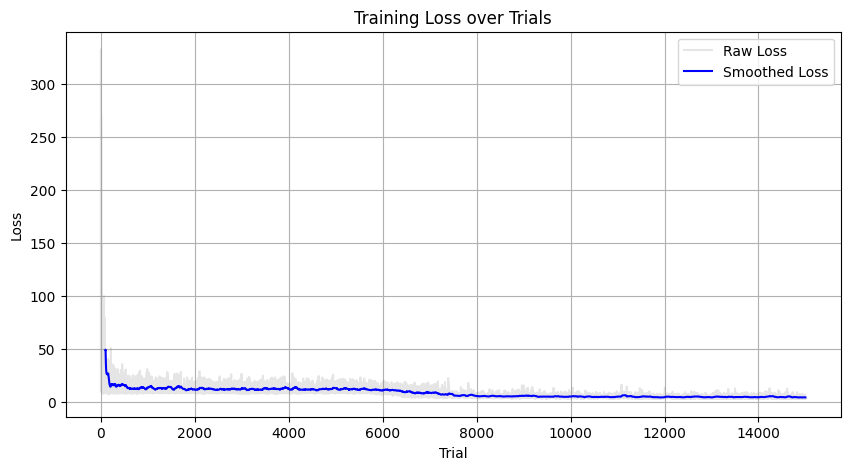

In [ ]:
plt.figure(figsize=(10, 5))

window_size = 100
smoothed_losses = pd.Series(losses).rolling(window=window_size).mean()

plt.plot(losses, alpha=0.2, color='gray', label='Raw Loss')
plt.plot(smoothed_losses, color='blue', label='Smoothed Loss')

plt.title('Training Loss over Trials')
plt.xlabel('Trial')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()


In [25]:
print("=== Testing Trained Rate RNN on XOR Task ===")

xor_patterns = [
    ([-1, -1], 1, "Input (-1,-1)"),
    ([-1, 1], -1, "Input (-1,1)"),
    ([1, -1], -1, "Input (1,-1)"),
    ([1, 1], 1, "Input (1,1)")
]

# Test rate RNN
rate_results = []
rate_outputs = []

print("\nRate RNN Results:")
print("-" * 40)

for input_pattern, expected_output, pattern_name in xor_patterns:
    # Create input stimulus using the same format as generate_input_stim_xor
    T = settings['T']
    stim_on = settings['stim_on']
    stim_dur = settings['stim_dur']
    delay = settings['delay']
    
    task_end_time = stim_on + (2 * stim_dur) + delay
    target_onset = task_end_time + 10
    
    u_test = np.zeros((2, T))
    
    u_test[0, stim_on:stim_on+stim_dur] = input_pattern[0]
    u_test[1, stim_on+stim_dur+delay:stim_on+2*stim_dur+delay] = input_pattern[1]
    
    u_tensor = torch.tensor(u_test, dtype=torch.float32, device=device)
    
    with torch.no_grad():
        stim, x, r, o, w, w_in, m, som_m, w_out, b_out, taus_gaus = \
            net.forward(u_tensor, settings['taus'], training_params, settings)
        
        o_tensor = torch.stack(o, dim=0).squeeze()  # Shape: (T-1,)
    
        final_output = torch.mean(o_tensor[-10:]).item()
        
        rate_results.append({
            'pattern': input_pattern,
            'expected': expected_output,
            'actual': final_output,
            'name': pattern_name
        })
        
        rate_outputs.append(o_tensor.cpu().numpy().flatten())
        
        print(f"{pattern_name}: Expected={expected_output}, Actual={final_output:.4f}")

=== Testing Trained Rate RNN on XOR Task ===

Rate RNN Results:
----------------------------------------
Input (-1,-1): Expected=1, Actual=-0.2398
Input (-1,1): Expected=-1, Actual=-0.0690
Input (1,-1): Expected=-1, Actual=-0.5397
Input (1,1): Expected=1, Actual=0.2403


In [7]:
model_filename = 'rate_model_xor.mat'
model_dir = 'models/xor'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, model_filename)

model_dict = {
    'w': net.w.detach().cpu().numpy(),
    'w_in': net.w_in.detach().cpu().numpy(),
    'w_out': net.w_out.detach().cpu().numpy(),
    'w0': w0.detach().cpu().numpy(),
    'N': np.array(net.N),
    'm': net.mask.cpu().numpy(),
    'som_m': net.som_mask.cpu().numpy(),
    'inh': net.inh,
    'exc': net.exc,
    'taus': np.array(settings['taus']),
    'taus_gaus': taus_gaus.detach().cpu().numpy(),
    'taus_gaus0': taus_gaus0.detach().cpu().numpy(),
}
sio.savemat(model_path, model_dict)

print(f"Trained rate model saved to: {model_path}")

# Save the trained model
torch.save({
    'model_state_dict': net.state_dict(),
    # 'optimizer_state_dict': optimizer.state_dict(),
    'settings': settings,
    'training_params': training_params,
    'losses': losses,
    'final_loss': losses[-1],
    'trial': num_trials,
    }, model_path.replace('.mat', '.pth'))

Trained rate model saved to: models/xor/rate_model_xor.mat


In [8]:
# Run lambda grid search to find optimal scaling factor
print("\n=== Running Lambda Grid Search for Optimal Scaling ===")
opt_scaling_factor = lambda_grid_search(
    model_dir=model_dir,
    task_name='xor',
    n_trials=50,
    scaling_factors=list(np.arange(15, 76, 5))
)


=== Running Lambda Grid Search for Optimal Scaling ===


Analyzing rate_model_xor.mat for xor task
Testing scaling factor: 15
Performance for 15: 0.860
Testing scaling factor: 20
Performance for 20: 0.900
Testing scaling factor: 25
Performance for 25: 0.960
Testing scaling factor: 30
Performance for 30: 0.920
Testing scaling factor: 35
Performance for 35: 0.980
Testing scaling factor: 40
Performance for 40: 0.960
Testing scaling factor: 45
Performance for 45: 0.980
Testing scaling factor: 50
Performance for 50: 1.000
Testing scaling factor: 55
Performance for 55: 0.980
Testing scaling factor: 60
Performance for 60: 0.980
Testing scaling factor: 65
Performance for 65: 0.940
Testing scaling factor: 70
Performance for 70: 0.920
Testing scaling factor: 75
Performance for 75: 0.780
Best scaling factor: 50
Saved results.


In [27]:

spiking_results = []
spiking_outputs = []
spike_trains = []

print("\nSpiking Network Results:")
print("-" * 40)

for input_pattern, expected_output, pattern_name in xor_patterns:
    T = settings['T']
    stim_on = settings['stim_on']
    stim_dur = settings['stim_dur']
    delay = settings['delay']
    
    u_spike = np.zeros((2, T))
    
    u_spike[0, stim_on : stim_on + stim_dur] = input_pattern[0]
    u_spike[1, stim_on + stim_dur + delay : stim_on + 2 * stim_dur + delay] = input_pattern[1]

    # Run the LIF simulation
    stims = {'mode': 'none'}
    W, REC, spk, rs, all_fr, out, params = LIF_network_fnc(
        model_path, opt_scaling_factor, u_spike, stims, 1, False
    )
    
    final_output = np.mean(out[-10:])

    spiking_results.append({
        'pattern': input_pattern,
        'expected': expected_output,
        'actual': final_output,
        'name': pattern_name
    })
    
    spiking_outputs.append(out.flatten())
    spike_trains.append(spk)
    
    print(f"{pattern_name}: Expected={expected_output}, Actual={final_output:.4f}")



Spiking Network Results:
----------------------------------------
Input (-1,-1): Expected=1, Actual=0.1263
Input (-1,1): Expected=-1, Actual=0.0912
Input (1,-1): Expected=-1, Actual=-0.5208
Input (1,1): Expected=1, Actual=-0.2848


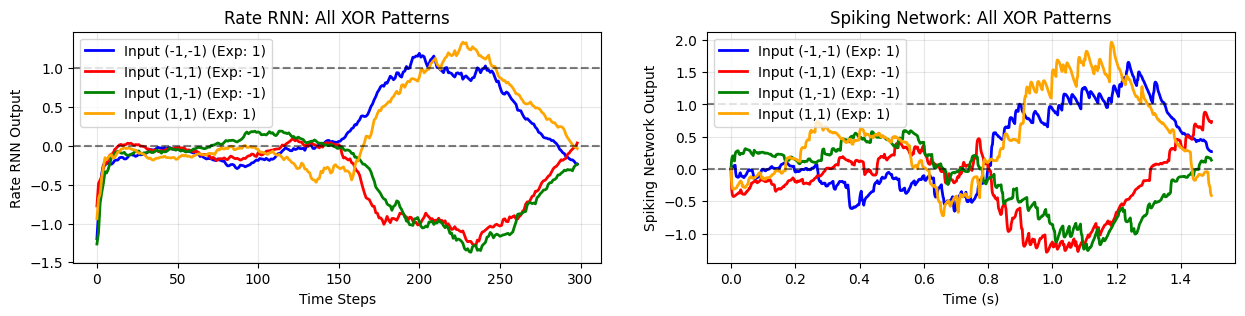

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

# Rate RNN outputs
ax = axes[0]
colors = ['blue', 'red', 'green', 'orange']
t_rate = np.arange(len(rate_outputs[0])) * settings['DeltaT']

for i, (output, result) in enumerate(zip(rate_outputs, rate_results)):
    ax.plot(t_rate, output, colors[i], linewidth=2, label=f'{result["name"]} (Exp: {result["expected"]})')
    
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.axhline(y=1, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Time Steps')
ax.set_ylabel('Rate RNN Output')
ax.set_title('Rate RNN: All XOR Patterns')
ax.legend()
ax.grid(True, alpha=0.3)

# Spiking network outputs
ax = axes[1]
dt = params['dt']
t_spike = np.arange(len(spiking_outputs[0])) * dt

for i, (output, result) in enumerate(zip(spiking_outputs, spiking_results)):
    ax.plot(t_spike, output, colors[i], linewidth=2, label=f'{result["name"]} (Exp: {result["expected"]})')
    
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.axhline(y=1, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Spiking Network Output')
ax.set_title('Spiking Network: All XOR Patterns')
ax.legend()
ax.grid(True, alpha=0.3)

